In [125]:
%pip install pandas scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [126]:
print("Welcome to my Machine Learning Project")

Welcome to my Machine Learning Project


In [127]:
print("Project: Does a model that performs well on one dataset necessarily generalize to another?")

Project: Does a model that performs well on one dataset necessarily generalize to another?


In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
print("All libraries imported successfully!")

All libraries imported successfully!


In [129]:
import os
import urllib.request
import zipfile
from pathlib import Path
project_folder = Path("ML_Cross_Dataset_Project")
project_folder.mkdir(exist_ok=True)
data_folder = project_folder / "datasets"
data_folder.mkdir(exist_ok=True)
print("Project folders created successfully!")


Project folders created successfully!


In [130]:
print("Current working directory:", os.getcwd())

Current working directory: C:\Users\litty


In [131]:
enron_folder = data_folder / "enron"

In [132]:
enron_folder.mkdir(exist_ok=True)

In [133]:
print("Enron dataset folder created!")

Enron dataset folder created!


In [134]:
import pandas as pd

In [135]:
print("Ready to load the Enron spam dataset.")

Ready to load the Enron spam dataset.


In [136]:
dataset_url = "https://github.com/MWiechmann/enron_spam_data/raw/refs/heads/master/enron_spam_data.zip"

In [137]:
response = requests.get(dataset_url, timeout=120)

In [138]:
print("Status code:", response.status_code)
print("File size:", len(response.content), "bytes")

Status code: 200
File size: 15642124 bytes


In [139]:
zip_path = data_folder / "enron_spam_data.zip"

In [140]:
print("Enron ZIP file saved successfully!")

Enron ZIP file saved successfully!


In [141]:
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(enron_folder)

In [142]:
print("ZIP file exists:", zip_path.exists())
print("ZIP file size:", zip_path.stat().st_size, "bytes")

ZIP file exists: True
ZIP file size: 15642124 bytes


In [143]:
print("ZIP file contents:")
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    print(zip_ref.namelist())

ZIP file contents:
['enron_spam_data.csv']


In [21]:
enron_file = enron_folder / "enron_spam_data.csv"

In [24]:
with open(enron_file, "wb") as file:
    file.write(response.content)

print("Dataset downloaded successfully!")

Dataset downloaded successfully!


In [145]:
print("File size:", enron_file.stat().st_size, "bytes")

NameError: name 'enron_file' is not defined

In [146]:
print(enron_file.read_text())

NameError: name 'enron_file' is not defined

In [147]:
from pathlib import Path
import zipfile
import os

print("Python setup restored")

Python setup restored


In [148]:
print("Current folder:")
print(os.getcwd())

Current folder:
C:\Users\litty


In [149]:
zip_files = list(Path(".").rglob("*.zip"))

print("ZIP files found:")
for file in zip_files:
    print(file)

ZIP files found:
Downloads\attachments.zip
Downloads\BalancingWii-master.zip
Downloads\delvin-20260603T071441Z-3-001.zip
Downloads\delvin-20260603T071441Z-3-002.zip
Downloads\delvin-20260603T071441Z-3-003.zip
Downloads\delvin-20260603T071441Z-3-004.zip
Downloads\Files (1) - Copy.zip
Downloads\Files (1).zip
Downloads\files (2).zip
Downloads\Files.zip
Downloads\myairbridge-eOJ04uqTCgJ.zip
Downloads\select-20260609T131629Z-3-001.zip
Downloads\select-20260609T131629Z-3-002.zip
Downloads\select-20260609T131629Z-3-003.zip
Downloads\select-20260609T131629Z-3-004.zip
Downloads\select-20260609T131629Z-3-005.zip
Downloads\select-20260609T131629Z-3-006.zip
Downloads\WeightBalanceApp.zip
Downloads\WhatsApp Unknown 2025-10-24 at 6.31.10 AM.zip
Downloads\WhatsApp Unknown 2026-07-04 at 10.40.44 PM.zip
Downloads\WhatsApp Unknown 2026-07-14 at 7.46.56 AM.zip
Downloads\Wub.zip
PycharmProjects\PyCharm Community Edition 2024.2.4\skeletons\skeletons-win-403-python-3.10.8.zip
PycharmProjects\PyCharm Communi

In [15]:
from pathlib import Path
import zipfile

project_folder = Path("ML_Cross_Dataset_Project")
data_folder = project_folder / "datasets"
enron_folder = data_folder / "enron"
zip_path = data_folder / "enron_spam_data.zip"

print("ZIP path:", zip_path)
print("ZIP exists:", zip_path.exists())

ZIP path: ML_Cross_Dataset_Project\datasets\enron_spam_data.zip
ZIP exists: False


In [17]:
if zip_path.exists():
    print("ZIP size:", zip_path.stat().st_size, "bytes")
else:
    print("ZIP file was not found.")

ZIP file was not found.


In [19]:
import requests

zip_url = "https://github.com/MWiechmann/enron_spam_data/raw/refs/heads/master/enron_spam_data.zip"

response = requests.get(zip_url, timeout=120)

print("Status code:", response.status_code)
print("Downloaded size:", len(response.content), "bytes")

Status code: 200
Downloaded size: 15642124 bytes


In [21]:
data_folder.mkdir(parents=True, exist_ok=True)
enron_folder.mkdir(parents=True, exist_ok=True)

with open(zip_path, "wb") as file:
    file.write(response.content)

print("ZIP file saved!")

ZIP file saved!


In [23]:
print("ZIP exists:", zip_path.exists())
print("ZIP size:", zip_path.stat().st_size, "bytes")

ZIP exists: True
ZIP size: 15642124 bytes


In [25]:
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(enron_folder)

print("Enron dataset extracted successfully!")

Enron dataset extracted successfully!


In [27]:
print("Files inside Enron folder:")
for file in enron_folder.rglob("*"):
    if file.is_file():
        print(file)

Files inside Enron folder:
ML_Cross_Dataset_Project\datasets\enron\enron_spam_data.csv


In [34]:
enron_df = pd.read_csv(enron_folder / "enron_spam_data.csv")

print("Enron dataset loaded!")
print("Shape:", enron_df.shape)
print("Columns:", enron_df.columns.tolist())

Enron dataset loaded!
Shape: (33716, 5)
Columns: ['Message ID', 'Subject', 'Message', 'Spam/Ham', 'Date']


In [35]:
enron_df.head()

,Message ID,Subject,Message,Spam/Ham,Date
0,0,christmas tree farm pictures,NaN,ham,1999-12-10
1,1,"vastar resources , inc .","gary , production from the high island larger ...",ham,1999-12-13
2,2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,1999-12-14
3,3,re : issue,fyi - see note below - already done .\nstella\...,ham,1999-12-14
4,4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14


In [37]:
print(enron_df["Spam/Ham"].value_counts())

Spam/Ham
spam    17171
ham     16545
Name: count, dtype: int64


In [39]:
enron_df = enron_df.dropna(subset=["Message"])

In [41]:
enron_df["text"] = (
    enron_df["Subject"].fillna("") + " " +
    enron_df["Message"].fillna("")
)

In [43]:
enron_df["label"] = enron_df["Spam/Ham"].map({
    "ham": 0,
    "spam": 1
})

In [45]:
print(enron_df[["text", "label"]].head())

                                                text  label
1  vastar resources , inc . gary , production fro...      0
2  calpine daily gas nomination - calpine daily g...      0
3  re : issue fyi - see note below - already done...      0
4  meter 7268 nov allocation fyi .\n- - - - - - -...      0
5  mcmullen gas for 11 / 99 jackie ,\nsince the i...      0


In [47]:
print("Enron labels:")
print(enron_df["label"].value_counts())

Enron labels:
label
1    16852
0    16493
Name: count, dtype: int64


In [49]:
enron_train, enron_test = train_test_split(
    enron_df[["text", "label"]],
    test_size=0.20,
    random_state=42,
    stratify=enron_df["label"]
)

In [51]:
print("Enron training samples:", len(enron_train))
print("Enron testing samples:", len(enron_test))

Enron training samples: 26676
Enron testing samples: 6669


In [53]:
spamassassin_folder = data_folder / "spamassassin"
spamassassin_folder.mkdir(parents=True, exist_ok=True)

print("SpamAssassin folder created!")

SpamAssassin folder created!


In [56]:
import tarfile
from email import policy
from email.parser import BytesParser

In [58]:
spamassassin_urls = {
    "easy_ham": "https://spamassassin.apache.org/old/publiccorpus/20030228_easy_ham.tar.bz2",
    "hard_ham": "https://spamassassin.apache.org/old/publiccorpus/20030228_hard_ham.tar.bz2",
    "spam": "https://spamassassin.apache.org/old/publiccorpus/20030228_spam.tar.bz2"
}

print("SpamAssassin download links ready.")

SpamAssassin download links ready.


In [60]:
for name, url in spamassassin_urls.items():
    file_path = spamassassin_folder / f"{name}.tar.bz2"
    
    if not file_path.exists():
        response = requests.get(url, timeout=120)
        print(name, "status:", response.status_code)
        
        with open(file_path, "wb") as f:
            f.write(response.content)
    else:
        print(name, "already downloaded")

easy_ham already downloaded
hard_ham already downloaded
spam already downloaded


In [62]:
print("Downloaded files:")

for file in spamassassin_folder.iterdir():
    print(file.name, file.stat().st_size, "bytes")

Downloaded files:
easy_ham.tar.bz2 1612216 bytes
hard_ham.tar.bz2 1029898 bytes
spam.tar.bz2 1183768 bytes


In [64]:
for name in spamassassin_urls:
    archive = spamassassin_folder / f"{name}.tar.bz2"
    
    with tarfile.open(archive, "r:bz2") as tar:
        tar.extractall(spamassassin_folder)

print("SpamAssassin files extracted successfully!")

C:\Users\litty\AppData\Local\Temp\ipykernel_17060\4076997384.py:5: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(spamassassin_folder)


SpamAssassin files extracted successfully!


In [66]:
for file in spamassassin_folder.rglob("*"):
    if file.is_file():
        print(file)

ML_Cross_Dataset_Project\datasets\spamassassin\easy_ham.tar.bz2
ML_Cross_Dataset_Project\datasets\spamassassin\hard_ham.tar.bz2
ML_Cross_Dataset_Project\datasets\spamassassin\spam.tar.bz2
ML_Cross_Dataset_Project\datasets\spamassassin\easy_ham\00001.7c53336b37003a9286aba55d2945844c
ML_Cross_Dataset_Project\datasets\spamassassin\easy_ham\00002.9c4069e25e1ef370c078db7ee85ff9ac
ML_Cross_Dataset_Project\datasets\spamassassin\easy_ham\00003.860e3c3cee1b42ead714c5c874fe25f7
ML_Cross_Dataset_Project\datasets\spamassassin\easy_ham\00004.864220c5b6930b209cc287c361c99af1
ML_Cross_Dataset_Project\datasets\spamassassin\easy_ham\00005.bf27cdeaf0b8c4647ecd61b1d09da613
ML_Cross_Dataset_Project\datasets\spamassassin\easy_ham\00006.253ea2f9a9cc36fa0b1129b04b806608
ML_Cross_Dataset_Project\datasets\spamassassin\easy_ham\00007.37a8af848caae585af4fe35779656d55
ML_Cross_Dataset_Project\datasets\spamassassin\easy_ham\00008.5891548d921601906337dcf1ed8543cb
ML_Cross_Dataset_Project\datasets\spamassassin\easy_

In [68]:
def read_email_file(file_path):
    try:
        with open(file_path, "rb") as f:
            message = BytesParser(policy=policy.default).parse(f)

        parts = []

        if message["subject"]:
            parts.append(str(message["subject"]))

        if message.is_multipart():
            for part in message.walk():
                if part.get_content_type() == "text/plain":
                    try:
                        content = part.get_content()
                        if content:
                            parts.append(content)
                    except:
                        pass
        else:
            try:
                content = message.get_content()
                if content:
                    parts.append(content)
            except:
                pass

        return " ".join(parts)

    except:
        return ""

In [70]:
spamassassin_data = []

for file_path in spamassassin_folder.rglob("*"):
    
    if not file_path.is_file():
        continue
        
    if file_path.suffix in [".bz2", ".zip", ".tar"]:
        continue
    
    path_text = str(file_path).lower()
    
    if "spam" in path_text and "easy_ham" not in path_text and "hard_ham" not in path_text:
        label = 1
    elif "easy_ham" in path_text or "hard_ham" in path_text:
        label = 0
    else:
        continue
    
    text = read_email_file(file_path)
    
    if text.strip():
        spamassassin_data.append({
            "text": text,
            "label": label
        })

print("Emails collected:", len(spamassassin_data))

Emails collected: 3252


In [73]:
spamassassin_df = pd.DataFrame(spamassassin_data)

print(spamassassin_df.shape)
print(spamassassin_df["label"].value_counts())

(3252, 2)
label
0    2752
1     500
Name: count, dtype: int64


In [75]:
spamassassin_df.head()

,text,label
0,"Re: New Sequences Window Date: Wed,...",0
1,[zzzzteana] RE: Alexander Martin A posted:\nTa...,0
2,[zzzzteana] Moscow bomber Man Threatens Explos...,0
3,[IRR] Klez: The Virus That Won't Die Klez: Th...,0
4,Re: [zzzzteana] Nothing like mama used to make...,0


In [77]:
spam_train, spam_test = train_test_split(
    spamassassin_df,
    test_size=0.20,
    random_state=42,
    stratify=spamassassin_df["label"]
)

In [79]:
print("SpamAssassin training samples:", len(spam_train))
print("SpamAssassin testing samples:", len(spam_test))

SpamAssassin training samples: 2601
SpamAssassin testing samples: 651


In [81]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        max_features=10000,
        ngram_range=(1, 2),
        min_df=2
    )),
    ("classifier", MultinomialNB(alpha=0.5))
])

print("Model created successfully!")

Model created successfully!


In [84]:
model.fit(
    enron_train["text"],
    enron_train["label"]
)

print("Model trained on Enron!")

Model trained on Enron!


In [87]:
enron_predictions = model.predict(enron_test["text"])

In [89]:
enron_accuracy = accuracy_score(
    enron_test["label"],
    enron_predictions
)

enron_precision = precision_score(
    enron_test["label"],
    enron_predictions
)

enron_recall = recall_score(
    enron_test["label"],
    enron_predictions
)

enron_f1 = f1_score(
    enron_test["label"],
    enron_predictions
)

print("ENRON → ENRON")
print("Accuracy :", enron_accuracy)
print("Precision:", enron_precision)
print("Recall   :", enron_recall)
print("F1 Score :", enron_f1)

ENRON → ENRON
Accuracy : 0.9847053531264057
Precision: 0.9811542991755006
Recall   : 0.9887240356083086
F1 Score : 0.9849246231155779


In [92]:
cross_predictions_1 = model.predict(spam_test["text"])

In [94]:
cross_accuracy_1 = accuracy_score(
    spam_test["label"],
    cross_predictions_1
)

cross_precision_1 = precision_score(
    spam_test["label"],
    cross_predictions_1
)

cross_recall_1 = recall_score(
    spam_test["label"],
    cross_predictions_1
)

cross_f1_1 = f1_score(
    spam_test["label"],
    cross_predictions_1
)

print("ENRON → SPAMASSASSIN")
print("Accuracy :", cross_accuracy_1)
print("Precision:", cross_precision_1)
print("Recall   :", cross_recall_1)
print("F1 Score :", cross_f1_1)

ENRON → SPAMASSASSIN
Accuracy : 0.29339477726574503
Precision: 0.17625899280575538
Recall   : 0.98
F1 Score : 0.29878048780487804


In [96]:
model_spam = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        max_features=10000,
        ngram_range=(1, 2),
        min_df=2
    )),
    ("classifier", MultinomialNB(alpha=0.5))
])

In [99]:
model_spam.fit(
    spam_train["text"],
    spam_train["label"]
)

print("Model trained on SpamAssassin!")

Model trained on SpamAssassin!


In [103]:
spam_predictions = model_spam.predict(spam_test["text"])

In [105]:
spam_accuracy = accuracy_score(
    spam_test["label"],
    spam_predictions
)

spam_precision = precision_score(
    spam_test["label"],
    spam_predictions
)

spam_recall = recall_score(
    spam_test["label"],
    spam_predictions
)

spam_f1 = f1_score(
    spam_test["label"],
    spam_predictions
)

print("SPAMASSASSIN → SPAMASSASSIN")
print("Accuracy :", spam_accuracy)
print("Precision:", spam_precision)
print("Recall   :", spam_recall)
print("F1 Score :", spam_f1)

SPAMASSASSIN → SPAMASSASSIN
Accuracy : 0.9447004608294931
Precision: 0.8137254901960784
Recall   : 0.83
F1 Score : 0.8217821782178217


In [107]:
cross_predictions_2 = model_spam.predict(enron_test["text"])

In [109]:
cross_accuracy_2 = accuracy_score(
    enron_test["label"],
    cross_predictions_2
)

cross_precision_2 = precision_score(
    enron_test["label"],
    cross_predictions_2
)

cross_recall_2 = recall_score(
    enron_test["label"],
    cross_predictions_2
)

cross_f1_2 = f1_score(
    enron_test["label"],
    cross_predictions_2
)

print("SPAMASSASSIN → ENRON")
print("Accuracy :", cross_accuracy_2)
print("Precision:", cross_precision_2)
print("Recall   :", cross_recall_2)
print("F1 Score :", cross_f1_2)

SPAMASSASSIN → ENRON
Accuracy : 0.6078872394661868
Precision: 0.9564691656590084
Recall   : 0.23471810089020773
F1 Score : 0.37693590659995235


In [111]:
results = pd.DataFrame({
    "Experiment": [
        "Enron → Enron",
        "Enron → SpamAssassin",
        "SpamAssassin → SpamAssassin",
        "SpamAssassin → Enron"
    ],
    "Accuracy": [
        enron_accuracy,
        cross_accuracy_1,
        spam_accuracy,
        cross_accuracy_2
    ],
    "Precision": [
        enron_precision,
        cross_precision_1,
        spam_precision,
        cross_precision_2
    ],
    "Recall": [
        enron_recall,
        cross_recall_1,
        spam_recall,
        cross_recall_2
    ],
    "F1 Score": [
        enron_f1,
        cross_f1_1,
        spam_f1,
        cross_f1_2
    ]
})

results

,Experiment,Accuracy,Precision,Recall,F1 Score
0,Enron → Enron,0.984705,0.981154,0.988724,0.984925
1,Enron → SpamAssassin,0.293395,0.176259,0.980000,0.298780
2,SpamAssassin → SpamAssassin,0.944700,0.813725,0.830000,0.821782
3,SpamAssassin → Enron,0.607887,0.956469,0.234718,0.376936


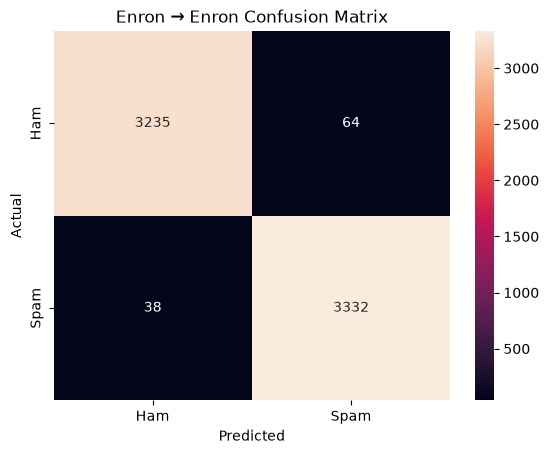

In [113]:
cm_enron = confusion_matrix(
    enron_test["label"],
    enron_predictions
)

sns.heatmap(
    cm_enron,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Enron → Enron Confusion Matrix")
plt.show()

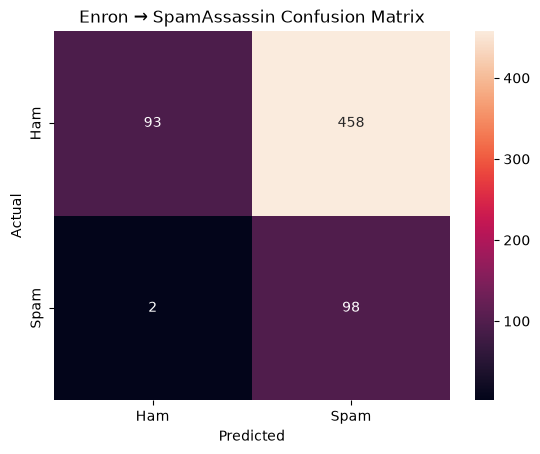

In [115]:
cm_cross1 = confusion_matrix(
    spam_test["label"],
    cross_predictions_1
)

sns.heatmap(
    cm_cross1,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Enron → SpamAssassin Confusion Matrix")
plt.show()

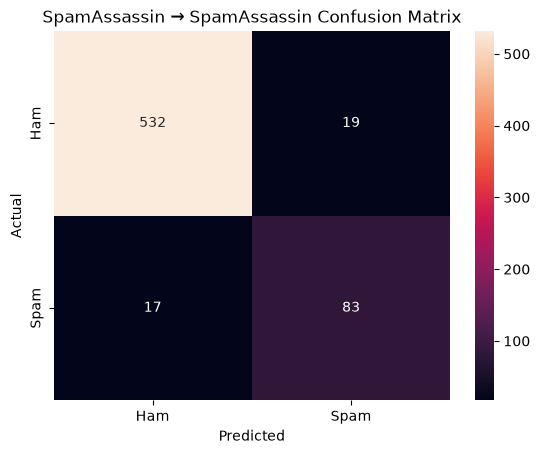

In [117]:
cm_spam = confusion_matrix(
    spam_test["label"],
    spam_predictions
)

sns.heatmap(
    cm_spam,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SpamAssassin → SpamAssassin Confusion Matrix")
plt.show()

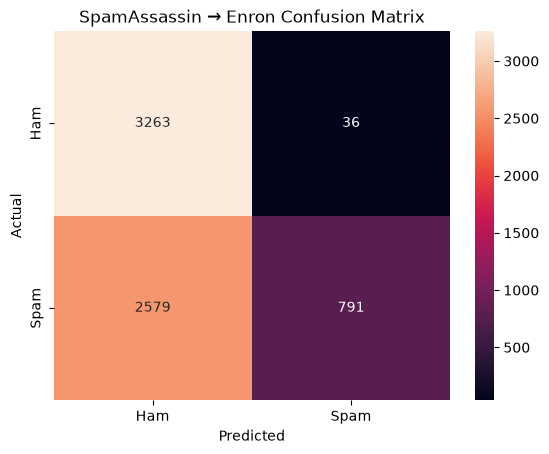

In [119]:
cm_cross2 = confusion_matrix(
    enron_test["label"],
    cross_predictions_2
)

sns.heatmap(
    cm_cross2,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SpamAssassin → Enron Confusion Matrix")
plt.show()

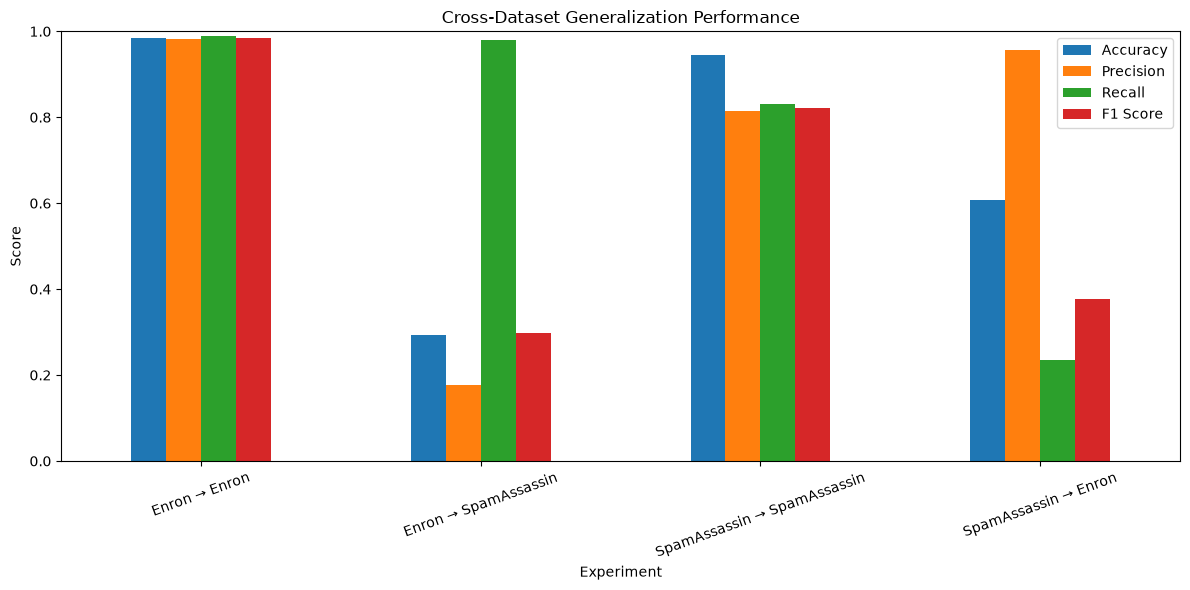

In [121]:
results.set_index("Experiment")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Cross-Dataset Generalization Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.show()

In [123]:
results.to_csv(
    project_folder / "final_results.csv",
    index=False
)

print("Results saved successfully!")

Results saved successfully!


In [124]:
print("Project folder:", project_folder.resolve())

Project folder: C:\Users\litty\ML_Cross_Dataset_Project
